(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

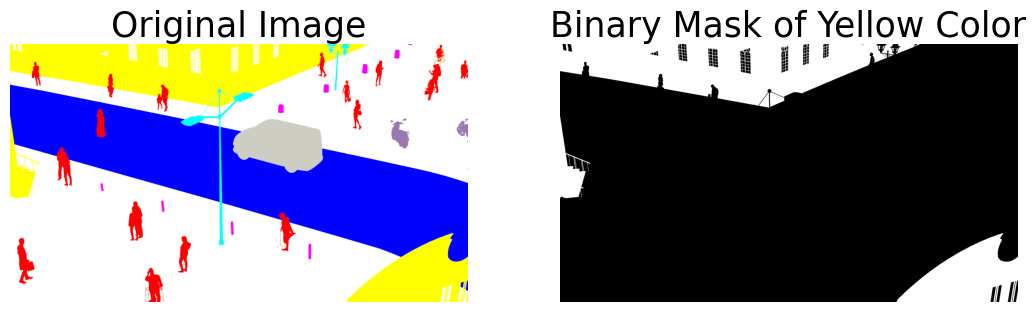

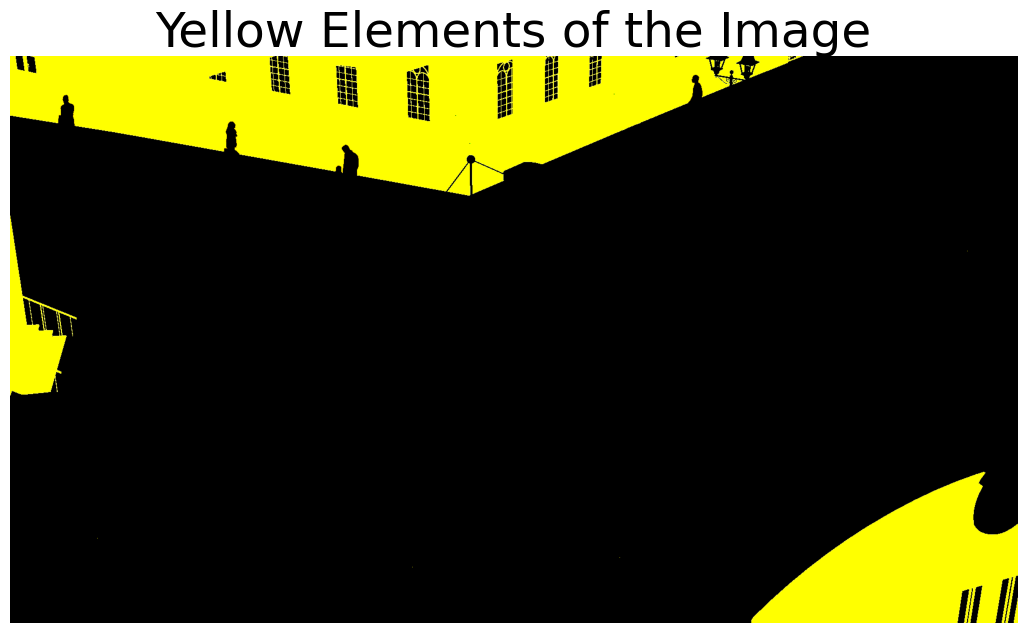

In [1]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para YELLOW ###

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Define limits for YELLOW Color >> HSV (255, 255, 30)
lower_bound = np.array([20, 100, 100])
upper_bound = np.array([60, 255, 255])  

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title("Original Image",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Yellow Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Yellow Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')